# FreshRAG Verification Stage Analysis
## Does Staleness Increase Hallucination and Verification Cost?

This notebook analyzes the verification stage (Stage 5) results across four staleness conditions:
- **Fresh (0%)**: All documents are current
- **Stale-10%**: 10% of answer-bearing docs replaced with outdated versions
- **Stale-30%**: 30% replaced
- **Stale-50%**: 50% replaced

NLI verifier: `cross-encoder/nli-deberta-v3-base`

Evaluation metrics:
- **Entailment failure rate**: Fraction of answers NOT entailed by context (hallucination flag)
- **Regeneration trigger rate**: Fraction of answers sent for regeneration
- **Total cost per verified answer**: Generation cost + any regeneration cost

Also examines: entailed-after-regen recovery rate, verification latency, and how upstream context quality (contradiction density, stale ratio) correlates with hallucination.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Style setup ──
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

COLORS = {
    'fresh': '#2ecc71',
    'stale_10': '#f1c40f',
    'stale_30': '#e67e22',
    'stale_50': '#e74c3c',
}
CONDITION_LABELS = {
    'fresh': 'Fresh (0%)',
    'stale_10': 'Stale 10%',
    'stale_30': 'Stale 30%',
    'stale_50': 'Stale 50%',
}
CONDITIONS = ['fresh', 'stale_10', 'stale_30', 'stale_50']
STALENESS_PCTS = [0, 10, 30, 50]

DOMAINS = ['covidqa', 'cuad', 'expertqa', 'finqa', 'techqa']
DOMAIN_LABELS = {
    'covidqa': 'Healthcare',
    'cuad': 'Legal',
    'expertqa': 'Expert/Cross-domain',
    'finqa': 'Finance',
    'techqa': 'SaaS/IT',
}

print('Setup complete.')

Setup complete.


In [2]:
# ── Load data ──
RESULTS_PATH = '../freshrag_experiment/results/verification_results_aggregated.json'
DETAILED_PATH = '../freshrag_experiment/results/verification_results_detailed.jsonl'

with open(RESULTS_PATH) as f:
    data = json.load(f)

detailed = []
with open(DETAILED_PATH) as f:
    for line in f:
        if line.strip():
            detailed.append(json.loads(line))

df = pd.DataFrame(detailed)

print(f'Sections: {list(data.keys())}')
print(f'Conditions: {list(data["overall"].keys())}')
print(f'Queries per condition: {data["overall"]["fresh"]["n"]}')
print(f'Total detailed records: {len(df)}')

Sections: ['overall', 'by_time_sensitivity', 'by_domain']
Conditions: ['fresh', 'stale_10', 'stale_30', 'stale_50']
Queries per condition: 289
Total detailed records: 1156


## 1. Overall Verification Metrics
Overview table of all metrics across staleness conditions.

In [3]:
# ── Build overview dataframe ──
overview_rows = []
for cond in CONDITIONS:
    d = data['overall'][cond]
    overview_rows.append({
        'Condition': CONDITION_LABELS[cond],
        'Staleness %': STALENESS_PCTS[CONDITIONS.index(cond)],
        'Entailment Failure Rate': d['entailment_failure_mean'],
        'Regen Trigger Rate': d['regeneration_triggered_mean'],
        'Entailed After Regen': d['entailed_after_regen_mean'],
        'Gen Cost/Query USD': d['generation_cost_usd_mean'],
        'Regen Cost/Query USD': d['regen_cost_usd_mean'],
        'Total Cost/Query USD': d['total_cost_usd_mean'],
        'Total Cost USD': d['total_cost_usd_sum'],
        'Verification Latency (ms)': d['verification_latency_ms_mean'],
        'Final Response Words': d['final_response_length_words_mean'],
        'n': d['n'],
    })

df_overview = pd.DataFrame(overview_rows)
df_overview.set_index('Condition', inplace=True)
df_overview.style.format({
    'Entailment Failure Rate': '{:.4f}',
    'Regen Trigger Rate': '{:.4f}',
    'Entailed After Regen': '{:.4f}',
    'Gen Cost/Query USD': '{:.6f}',
    'Regen Cost/Query USD': '{:.6f}',
    'Total Cost/Query USD': '{:.6f}',
    'Total Cost USD': '{:.4f}',
    'Verification Latency (ms)': '{:.1f}',
    'Final Response Words': '{:.1f}',
    'n': '{:.0f}',
}).background_gradient(cmap='RdYlGn_r', subset=['Entailment Failure Rate', 'Regen Trigger Rate', 'Total Cost USD']
).background_gradient(cmap='RdYlGn', subset=['Entailed After Regen'])

,Staleness %,Entailment Failure Rate,Regen Trigger Rate,Entailed After Regen,Gen Cost/Query USD,Regen Cost/Query USD,Total Cost/Query USD,Total Cost USD,Verification Latency (ms),Final Response Words,n
Condition,,,,,,,,,,,
Fresh (0%),0,0.9377,0.9377,0.0934,0.000531,0.000922,0.001453,0.4199,994.0,32.6,289
Stale 10%,10,0.9446,0.9446,0.0796,0.000532,0.000986,0.001518,0.4386,924.5,30.8,289
Stale 30%,30,0.9377,0.9377,0.1003,0.000532,0.000972,0.001504,0.4348,983.0,32.0,289
Stale 50%,50,0.9585,0.9585,0.0588,0.000528,0.000998,0.001526,0.4409,1047.2,29.5,289


## 2. Entailment Failure & Regeneration Rates
Does staleness increase hallucination and force more regeneration?

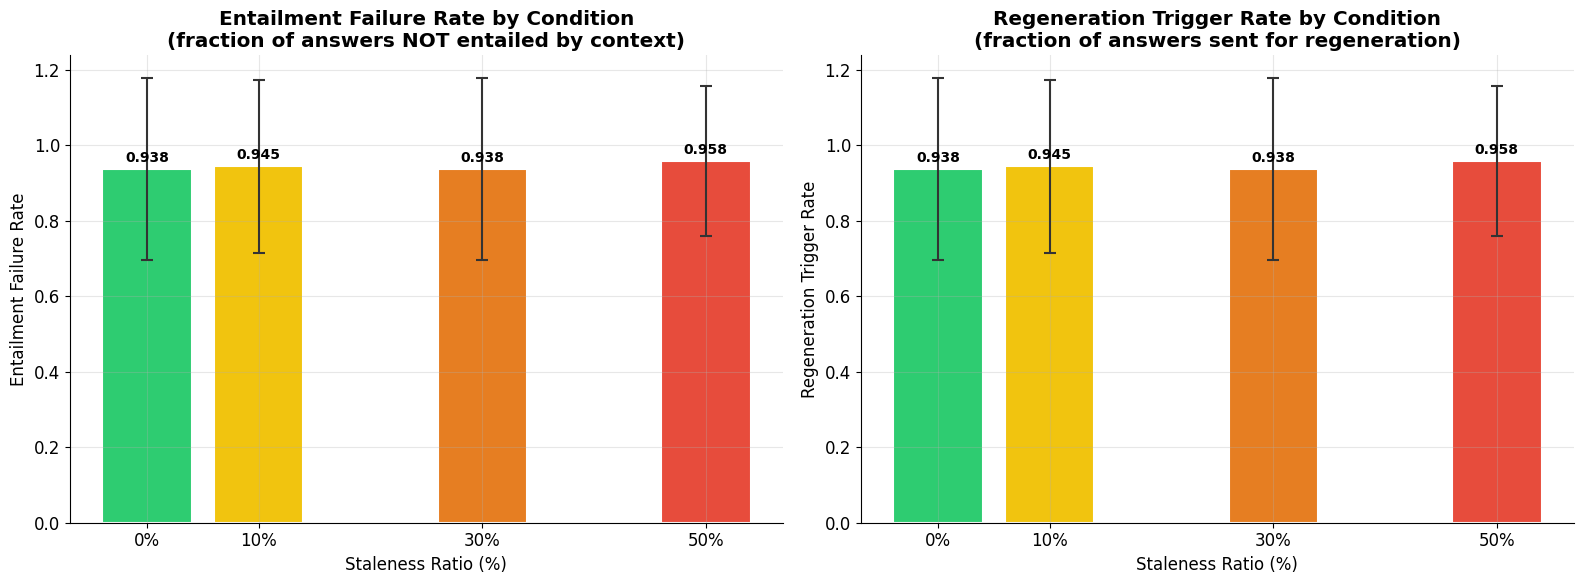

Saved: figures/fig34_failure_regen_rates.png


In [4]:
# ── Fig 34: Entailment failure rate & Regeneration trigger rate ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = [COLORS[c] for c in CONDITIONS]

# Entailment failure rate
ax = axes[0]
vals = [data['overall'][c]['entailment_failure_mean'] for c in CONDITIONS]
stds = [data['overall'][c]['entailment_failure_std'] for c in CONDITIONS]
bars = ax.bar(STALENESS_PCTS, vals, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.errorbar(STALENESS_PCTS, vals, yerr=stds, fmt='none', color='#333', capsize=4, capthick=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Entailment Failure Rate')
ax.set_title('Entailment Failure Rate by Condition\n(fraction of answers NOT entailed by context)', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Regeneration trigger rate
ax = axes[1]
vals = [data['overall'][c]['regeneration_triggered_mean'] for c in CONDITIONS]
stds = [data['overall'][c]['regeneration_triggered_std'] for c in CONDITIONS]
bars = ax.bar(STALENESS_PCTS, vals, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.errorbar(STALENESS_PCTS, vals, yerr=stds, fmt='none', color='#333', capsize=4, capthick=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Regeneration Trigger Rate')
ax.set_title('Regeneration Trigger Rate by Condition\n(fraction of answers sent for regeneration)', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/fig34_failure_regen_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig34_failure_regen_rates.png')

## 3. Regeneration Recovery & Verdict Distribution
How effective is regeneration at fixing hallucinations? What is the NLI verdict breakdown?

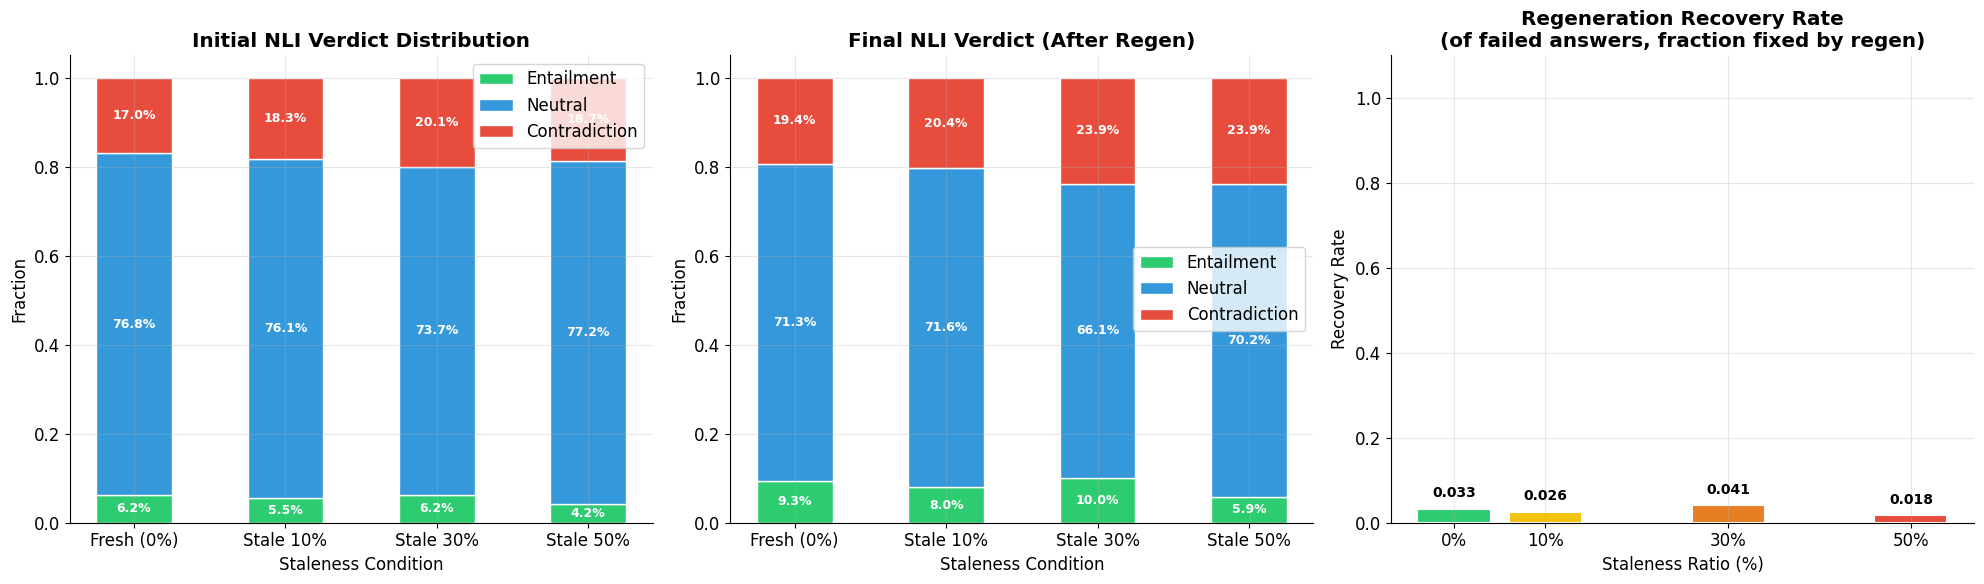

Saved: figures/fig35_verdict_recovery.png


In [5]:
# ── Fig 35: Verdict distribution (initial & final) + Recovery rate ──
from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Initial verdict distribution (stacked bar)
ax = axes[0]
x = np.arange(len(CONDITIONS))
width = 0.5

initial_counts = {}
for cond in CONDITIONS:
    subset = df[df['condition'] == cond]
    counter = Counter(subset['initial_verdict'])
    total = len(subset)
    initial_counts[cond] = {
        'entailment': counter.get('entailment', 0) / total if total else 0,
        'neutral': counter.get('neutral', 0) / total if total else 0,
        'contradiction': counter.get('contradiction', 0) / total if total else 0,
    }

ent_vals = [initial_counts[c]['entailment'] for c in CONDITIONS]
neu_vals = [initial_counts[c]['neutral'] for c in CONDITIONS]
con_vals = [initial_counts[c]['contradiction'] for c in CONDITIONS]

ax.bar(x, ent_vals, width, label='Entailment', color='#2ecc71', edgecolor='white')
ax.bar(x, neu_vals, width, bottom=ent_vals, label='Neutral', color='#3498db', edgecolor='white')
ax.bar(x, con_vals, width, bottom=[e+n for e,n in zip(ent_vals, neu_vals)],
       label='Contradiction', color='#e74c3c', edgecolor='white')
ax.set_xlabel('Staleness Condition')
ax.set_ylabel('Fraction')
ax.set_title('Initial NLI Verdict Distribution', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITIONS])
ax.legend()
ax.set_ylim(0, 1.05)

for i in range(len(CONDITIONS)):
    y_off = 0
    for val, lbl in [(ent_vals[i], 'E'), (neu_vals[i], 'N'), (con_vals[i], 'C')]:
        if val > 0.03:
            ax.text(i, y_off + val/2, f'{val:.1%}', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
        y_off += val

# Final verdict distribution (after regen)
ax = axes[1]
final_counts = {}
for cond in CONDITIONS:
    subset = df[df['condition'] == cond]
    counter = Counter(subset['final_verdict'])
    total = len(subset)
    final_counts[cond] = {
        'entailment': counter.get('entailment', 0) / total if total else 0,
        'neutral': counter.get('neutral', 0) / total if total else 0,
        'contradiction': counter.get('contradiction', 0) / total if total else 0,
    }

ent_vals = [final_counts[c]['entailment'] for c in CONDITIONS]
neu_vals = [final_counts[c]['neutral'] for c in CONDITIONS]
con_vals = [final_counts[c]['contradiction'] for c in CONDITIONS]

ax.bar(x, ent_vals, width, label='Entailment', color='#2ecc71', edgecolor='white')
ax.bar(x, neu_vals, width, bottom=ent_vals, label='Neutral', color='#3498db', edgecolor='white')
ax.bar(x, con_vals, width, bottom=[e+n for e,n in zip(ent_vals, neu_vals)],
       label='Contradiction', color='#e74c3c', edgecolor='white')
ax.set_xlabel('Staleness Condition')
ax.set_ylabel('Fraction')
ax.set_title('Final NLI Verdict (After Regen)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITIONS])
ax.legend()
ax.set_ylim(0, 1.05)

for i in range(len(CONDITIONS)):
    y_off = 0
    for val, lbl in [(ent_vals[i], 'E'), (neu_vals[i], 'N'), (con_vals[i], 'C')]:
        if val > 0.03:
            ax.text(i, y_off + val/2, f'{val:.1%}', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
        y_off += val

# Recovery rate: of those that failed, how many passed after regen
ax = axes[2]
recovery_rates = []
for cond in CONDITIONS:
    subset = df[(df['condition'] == cond) & (df['entailment_failure'] == 1)]
    if len(subset) > 0:
        recovered = subset['entailed_after_regen'].sum()
        recovery_rates.append(recovered / len(subset))
    else:
        recovery_rates.append(0)

colors_list = [COLORS[c] for c in CONDITIONS]
bars = ax.bar(STALENESS_PCTS, recovery_rates, width=8, color=colors_list, edgecolor='white', linewidth=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Recovery Rate')
ax.set_title('Regeneration Recovery Rate\n(of failed answers, fraction fixed by regen)', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
ax.set_ylim(0, 1.1)
for bar, val in zip(bars, recovery_rates):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/fig35_verdict_recovery.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig35_verdict_recovery.png')

## 4. Total Cost per Verified Answer
How does the cost of a verified answer scale with staleness?

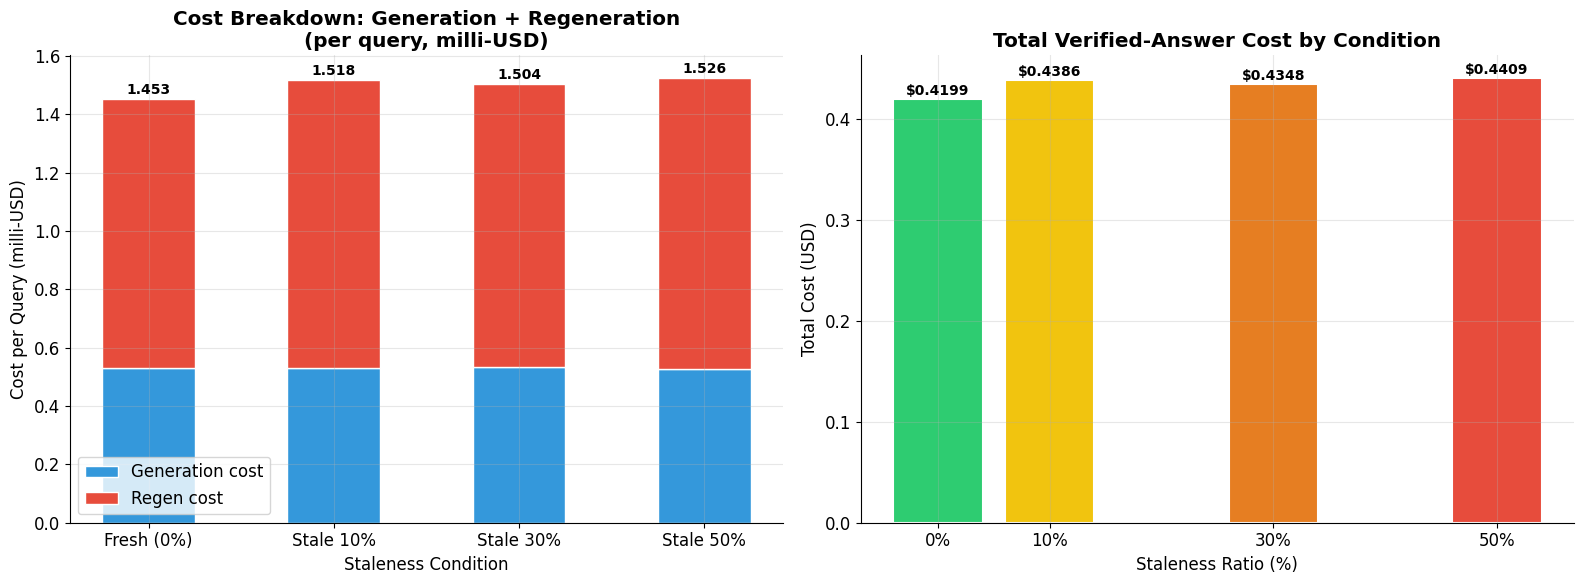

Saved: figures/fig36_verification_cost.png


In [6]:
# ── Fig 36: Cost breakdown — generation vs regeneration ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar: gen cost + regen cost
ax = axes[0]
x = np.arange(len(CONDITIONS))
width = 0.5

gen_costs = [data['overall'][c]['generation_cost_usd_mean'] * 1000 for c in CONDITIONS]  # milli-USD
regen_costs = [data['overall'][c]['regen_cost_usd_mean'] * 1000 for c in CONDITIONS]

bars1 = ax.bar(x, gen_costs, width, label='Generation cost', color='#3498db', edgecolor='white')
bars2 = ax.bar(x, regen_costs, width, bottom=gen_costs, label='Regen cost', color='#e74c3c', edgecolor='white')
ax.set_xlabel('Staleness Condition')
ax.set_ylabel('Cost per Query (milli-USD)')
ax.set_title('Cost Breakdown: Generation + Regeneration\n(per query, milli-USD)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITIONS])
ax.legend()

for i, (gc, rc) in enumerate(zip(gen_costs, regen_costs)):
    ax.text(i, gc + rc + 0.005, f'{gc+rc:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Total cost (sum) per condition
ax = axes[1]
total_sums = [data['overall'][c]['total_cost_usd_sum'] for c in CONDITIONS]
colors_list = [COLORS[c] for c in CONDITIONS]
bars = ax.bar(STALENESS_PCTS, total_sums, width=8, color=colors_list, edgecolor='white', linewidth=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Total Cost (USD)')
ax.set_title('Total Verified-Answer Cost by Condition', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, total_sums):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
            f'${val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/fig36_verification_cost.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig36_verification_cost.png')

## 5. Time-Sensitive vs. Time-Insensitive Comparison
Does staleness disproportionately increase hallucination for time-sensitive queries?

In [7]:
# ── Build time-sensitivity dataframe ──
ts_rows = []
for cond in CONDITIONS:
    for ts_label, ts_key in [('Time-Sensitive', 'time_sensitive'), ('Time-Insensitive', 'time_insensitive')]:
        key = f'{cond}__{ts_key}'
        d = data['by_time_sensitivity'].get(key, {})
        if d:
            ts_rows.append({
                'Condition': CONDITION_LABELS[cond],
                'Staleness %': STALENESS_PCTS[CONDITIONS.index(cond)],
                'Query Type': ts_label,
                'Entailment Failure Rate': d.get('entailment_failure_mean', 0),
                'Regen Trigger Rate': d.get('regeneration_triggered_mean', 0),
                'Entailed After Regen': d.get('entailed_after_regen_mean', 0),
                'Total Cost/Query USD': d.get('total_cost_usd_mean', 0),
            })

df_ts = pd.DataFrame(ts_rows)
print(df_ts.to_string(index=False, float_format='{:.4f}'.format))

 Condition  Staleness %       Query Type  Entailment Failure Rate  Regen Trigger Rate  Entailed After Regen  Total Cost/Query USD
Fresh (0%)            0   Time-Sensitive                   0.9353              0.9353                0.0935                0.0015
Fresh (0%)            0 Time-Insensitive                   0.9400              0.9400                0.0933                0.0014
 Stale 10%           10   Time-Sensitive                   0.9209              0.9209                0.1079                0.0015
 Stale 10%           10 Time-Insensitive                   0.9667              0.9667                0.0533                0.0016
 Stale 30%           30   Time-Sensitive                   0.9281              0.9281                0.1223                0.0015
 Stale 30%           30 Time-Insensitive                   0.9467              0.9467                0.0800                0.0015
 Stale 50%           50   Time-Sensitive                   0.9424              0.9424     

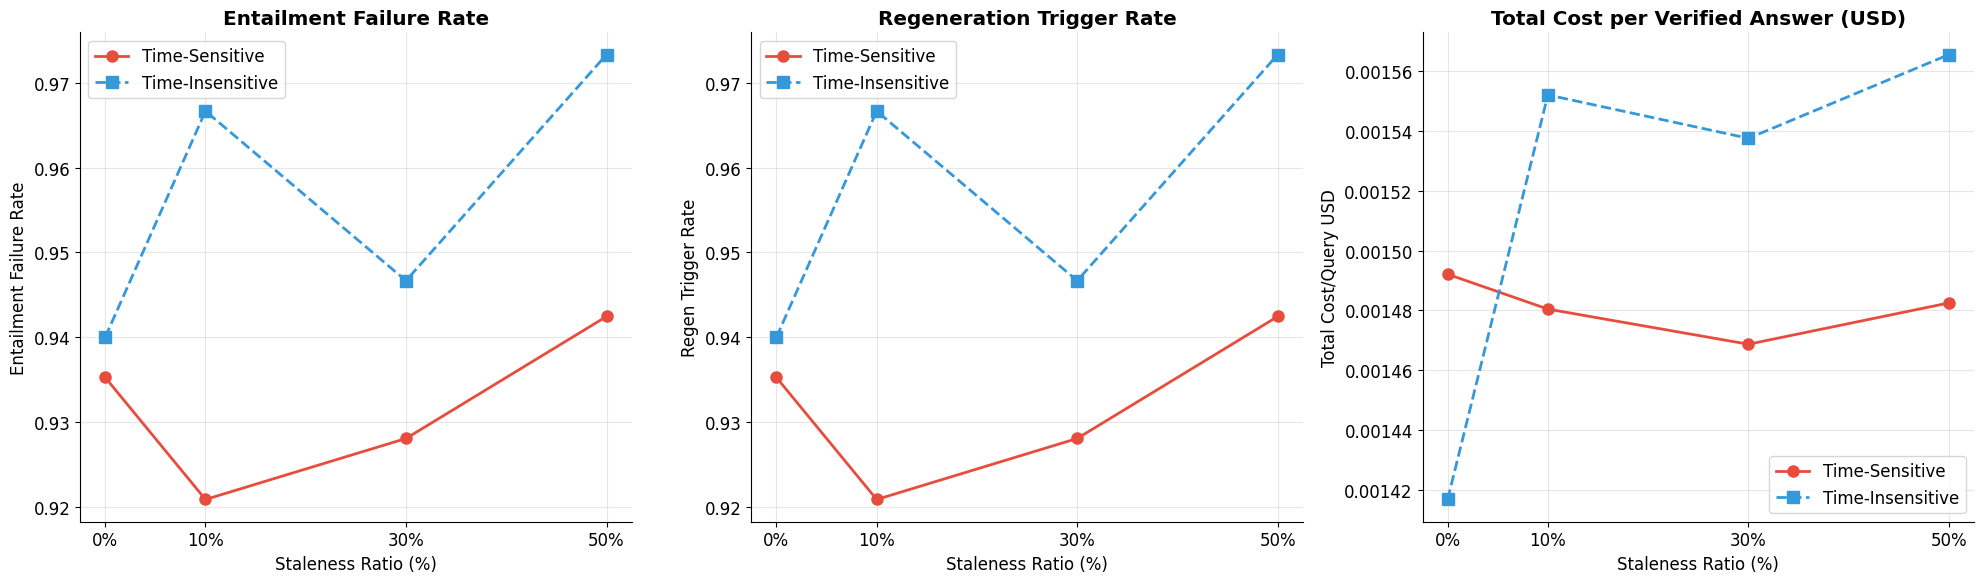

Saved: figures/fig37_verification_time_sensitivity.png


In [8]:
# ── Fig 37: Time-sensitivity comparison ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metric_configs = [
    ('Entailment Failure Rate', 'Entailment Failure Rate'),
    ('Regen Trigger Rate', 'Regeneration Trigger Rate'),
    ('Total Cost/Query USD', 'Total Cost per Verified Answer (USD)'),
]

for ax, (col, title) in zip(axes, metric_configs):
    for qt, style in [('Time-Sensitive', '-o'), ('Time-Insensitive', '--s')]:
        subset = df_ts[df_ts['Query Type'] == qt]
        color = '#e74c3c' if qt == 'Time-Sensitive' else '#3498db'
        ax.plot(subset['Staleness %'], subset[col], style,
                label=qt, color=color, linewidth=2, markersize=8)
    ax.set_xlabel('Staleness Ratio (%)')
    ax.set_ylabel(col)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(STALENESS_PCTS)
    ax.set_xticklabels(['0%', '10%', '30%', '50%'])
    ax.legend()

plt.tight_layout()
plt.savefig('../figures/fig37_verification_time_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig37_verification_time_sensitivity.png')

## 6. Domain-Level Analysis
Which domains are most prone to hallucination under staleness?

In [9]:
# ── Build domain dataframe ──
domain_rows = []
for cond in CONDITIONS:
    for domain in DOMAINS:
        key = f'{cond}__{domain}'
        d = data['by_domain'].get(key, {})
        if d:
            domain_rows.append({
                'Condition': CONDITION_LABELS[cond],
                'Staleness %': STALENESS_PCTS[CONDITIONS.index(cond)],
                'Domain': DOMAIN_LABELS.get(domain, domain),
                'domain_key': domain,
                'Entailment Failure Rate': d.get('entailment_failure_mean', 0),
                'Regen Trigger Rate': d.get('regeneration_triggered_mean', 0),
                'Total Cost/Query USD': d.get('total_cost_usd_mean', 0),
                'Entailed After Regen': d.get('entailed_after_regen_mean', 0),
                'n': d.get('n', 0),
            })

df_domain = pd.DataFrame(domain_rows)

pivot = df_domain.pivot_table(index='Domain', columns='Condition', values='Entailment Failure Rate')
pivot = pivot[[CONDITION_LABELS[c] for c in CONDITIONS]]
print('Entailment Failure Rate by Domain x Condition:')
print(pivot.to_string(float_format='{:.4f}'.format))

Entailment Failure Rate by Domain x Condition:
Condition            Fresh (0%)  Stale 10%  Stale 30%  Stale 50%
Domain                                                          
Expert/Cross-domain      0.9828     0.9828     0.9828     1.0000
Finance                  0.8500     0.8833     0.8833     0.9000
Healthcare               0.9483     0.9483     0.9483     0.9483
Legal                    0.9818     0.9818     0.9636     1.0000
SaaS/IT                  0.9310     0.9310     0.9138     0.9483


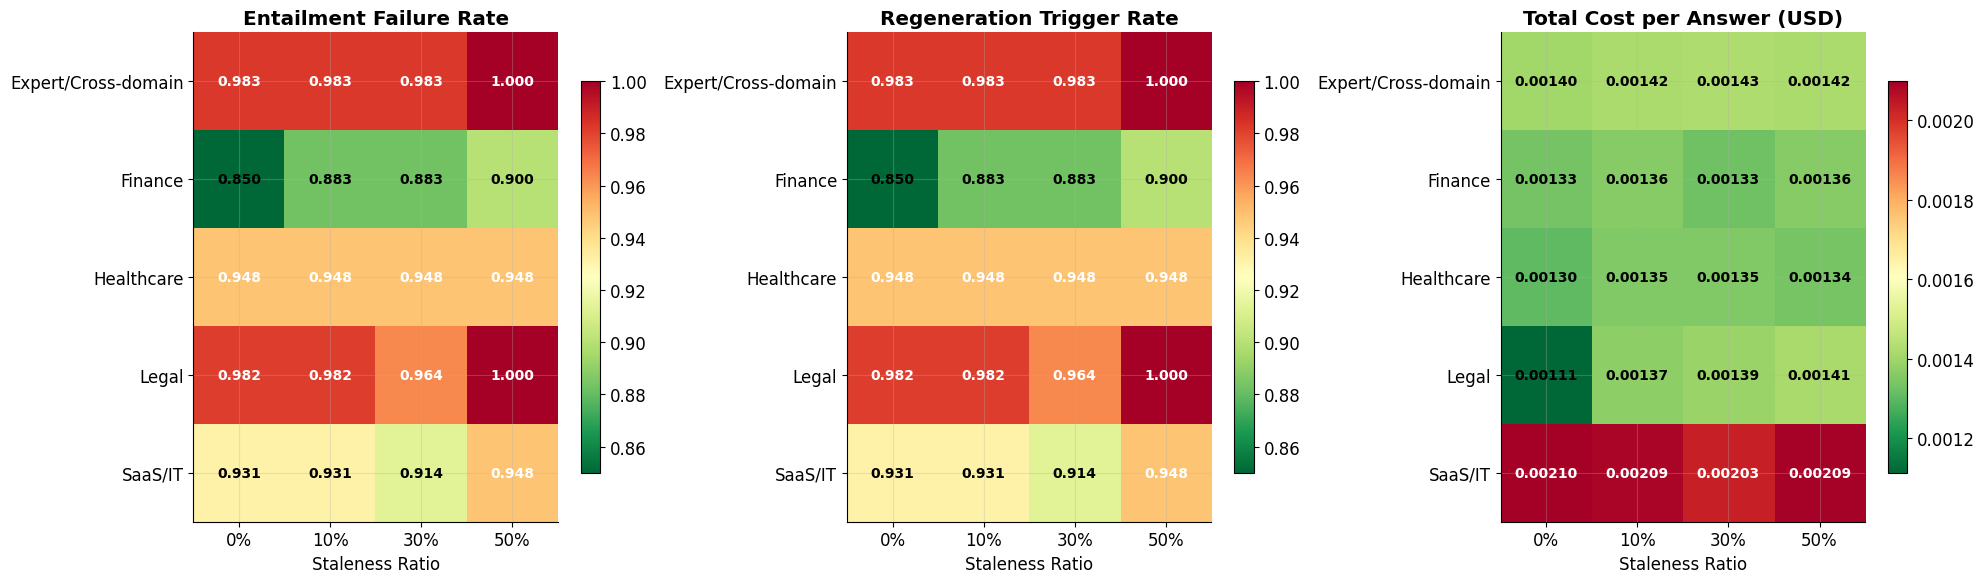

Saved: figures/fig38_verification_domain_heatmap.png


In [10]:
# ── Fig 38: Domain heatmaps ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

domain_metrics = [
    ('Entailment Failure Rate', 'Entailment Failure Rate', 'RdYlGn_r'),
    ('Regen Trigger Rate', 'Regeneration Trigger Rate', 'RdYlGn_r'),
    ('Total Cost/Query USD', 'Total Cost per Answer (USD)', 'RdYlGn_r'),
]

for ax, (metric, title, cmap) in zip(axes, domain_metrics):
    pivot = df_domain.pivot_table(index='Domain', columns='Staleness %', values=metric)
    pivot = pivot[[0, 10, 30, 50]]

    im = ax.imshow(pivot.values, cmap=cmap, aspect='auto')
    ax.set_xticks(range(4))
    ax.set_xticklabels(['0%', '10%', '30%', '50%'])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel('Staleness Ratio')
    ax.set_title(title, fontweight='bold')

    for i in range(len(pivot.index)):
        for j in range(4):
            val = pivot.values[i, j]
            fmt = f'{val:.3f}' if 'Cost' not in metric else f'{val:.5f}'
            text_color = 'white' if val > pivot.values.mean() else 'black'
            ax.text(j, i, fmt, ha='center', va='center',
                    fontsize=10, fontweight='bold', color=text_color)

    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('../figures/fig38_verification_domain_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig38_verification_domain_heatmap.png')

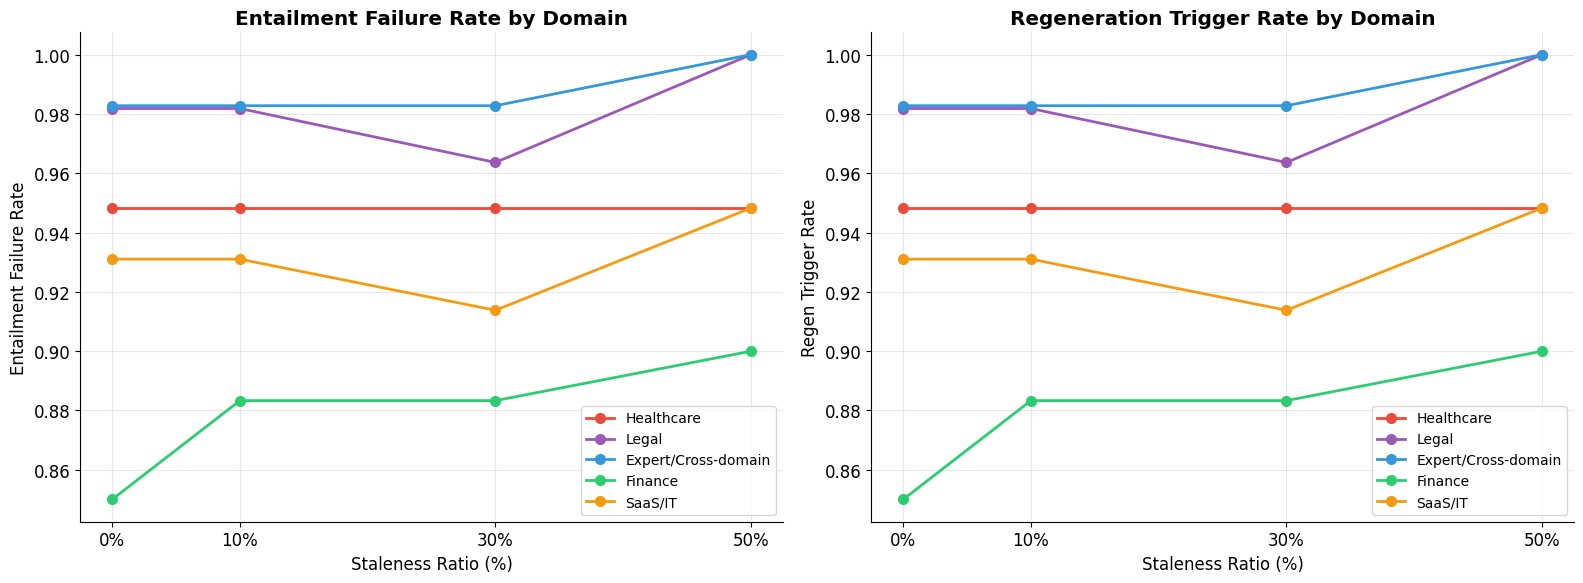

Saved: figures/fig39_verification_domain_curves.png


In [11]:
# ── Fig 39: Domain degradation curves ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

domain_colors = {
    'Healthcare': '#e74c3c',
    'Legal': '#9b59b6',
    'Expert/Cross-domain': '#3498db',
    'Finance': '#2ecc71',
    'SaaS/IT': '#f39c12',
}

for ax, metric, title in zip(axes,
    ['Entailment Failure Rate', 'Regen Trigger Rate'],
    ['Entailment Failure Rate by Domain', 'Regeneration Trigger Rate by Domain']):
    for domain_label in DOMAIN_LABELS.values():
        subset = df_domain[df_domain['Domain'] == domain_label]
        ax.plot(subset['Staleness %'], subset[metric], '-o',
                label=domain_label, color=domain_colors.get(domain_label, '#333'),
                linewidth=2, markersize=7)
    ax.set_xlabel('Staleness Ratio (%)')
    ax.set_ylabel(metric)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(STALENESS_PCTS)
    ax.set_xticklabels(['0%', '10%', '30%', '50%'])
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../figures/fig39_verification_domain_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig39_verification_domain_curves.png')

## 7. Context Quality vs. Hallucination
Do upstream context quality signals predict entailment failure?

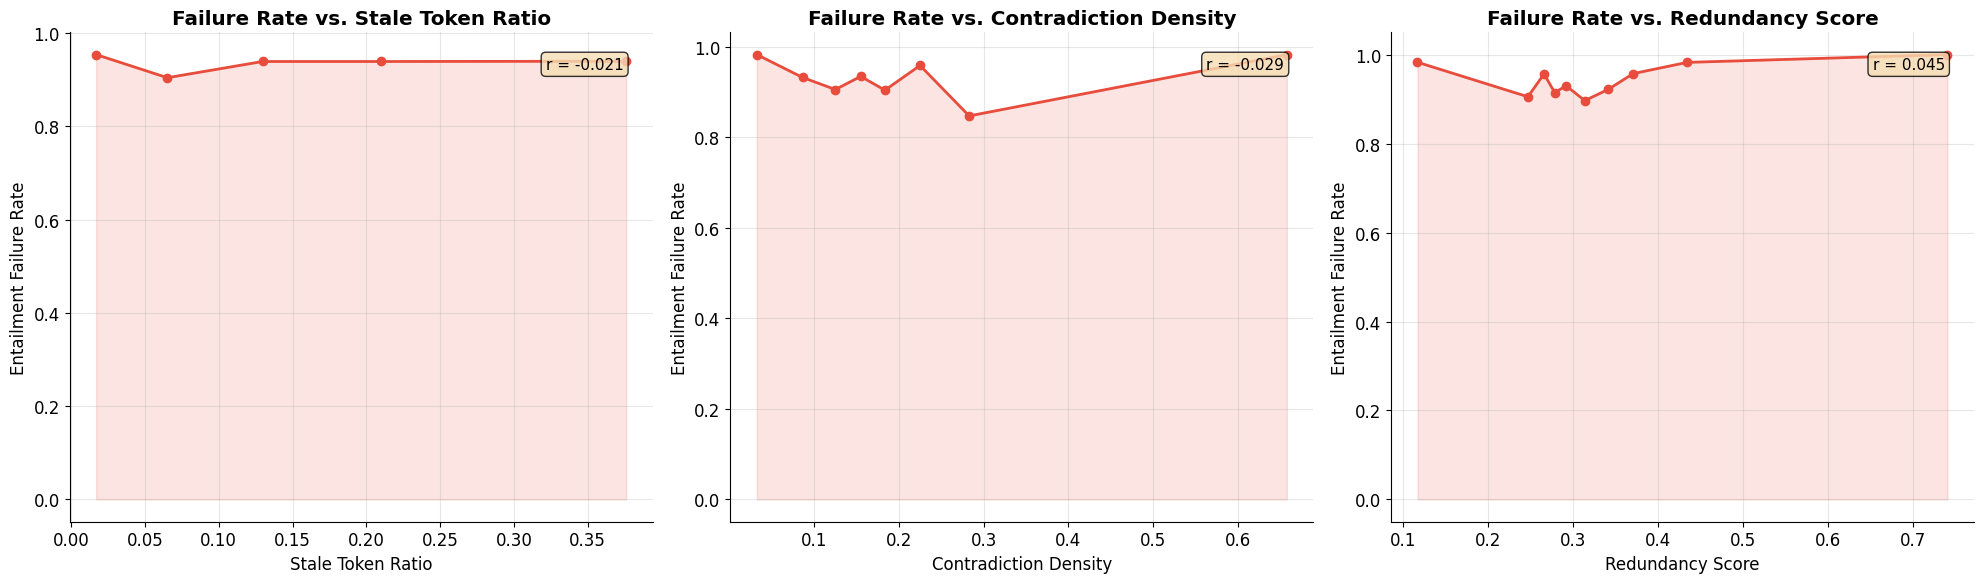

Saved: figures/fig40_context_vs_hallucination.png


In [12]:
# ── Fig 40: Entailment failure vs upstream signals ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Group by bins and show failure rate
scatter_configs = [
    ('stale_token_ratio', 'Stale Token Ratio'),
    ('contradiction_density', 'Contradiction Density'),
    ('redundancy_score', 'Redundancy Score'),
]

for ax, (col, x_label) in zip(axes, scatter_configs):
    # Bin the x variable and compute failure rate per bin
    df_plot = df[[col, 'entailment_failure', 'condition']].copy()
    df_plot['bin'] = pd.qcut(df_plot[col], q=10, duplicates='drop')

    bin_stats = df_plot.groupby('bin')['entailment_failure'].agg(['mean', 'count', 'sum'])
    bin_mids = [interval.mid for interval in bin_stats.index]

    ax.plot(bin_mids, bin_stats['mean'], '-o', color='#e74c3c', linewidth=2, markersize=6)
    ax.fill_between(bin_mids, 0, bin_stats['mean'], alpha=0.15, color='#e74c3c')
    ax.set_xlabel(x_label)
    ax.set_ylabel('Entailment Failure Rate')
    ax.set_title(f'Failure Rate vs. {x_label}', fontweight='bold')

    # Correlation
    x_vals = df[col].values
    y_vals = df['entailment_failure'].values
    mask = np.isfinite(x_vals) & np.isfinite(y_vals)
    if mask.sum() > 10:
        corr = np.corrcoef(x_vals[mask], y_vals[mask])[0, 1]
        ax.text(0.95, 0.95, f'r = {corr:.3f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=11,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('../figures/fig40_context_vs_hallucination.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig40_context_vs_hallucination.png')

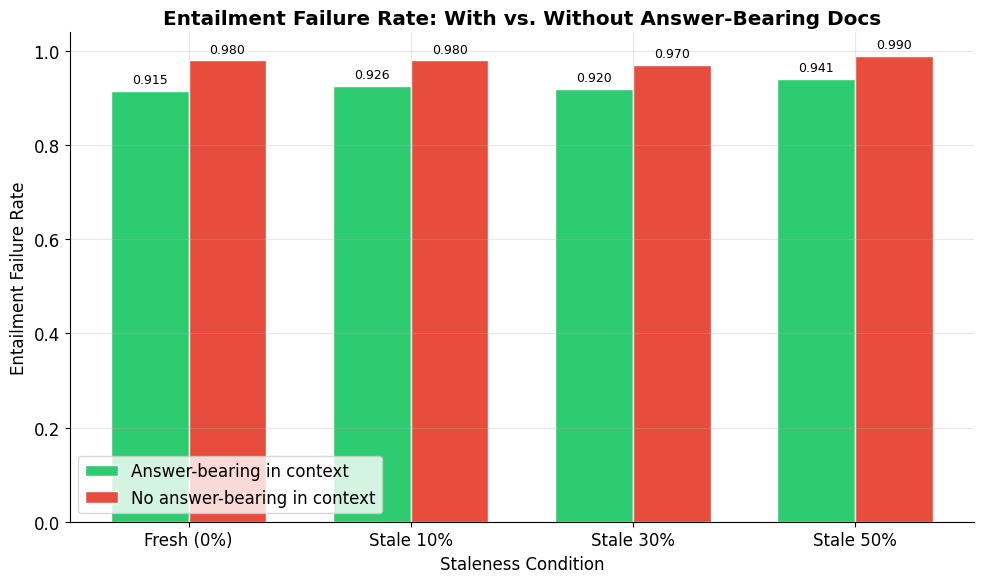

Saved: figures/fig41_answer_bearing_vs_failure.png


In [13]:
# ── Fig 41: Answer-bearing in context vs failure rate ──
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(CONDITIONS))
width = 0.35

fail_with_ab = []
fail_without_ab = []
for cond in CONDITIONS:
    subset_ab = df[(df['condition'] == cond) & (df['answer_bearing_in_context'] == True)]
    subset_no = df[(df['condition'] == cond) & (df['answer_bearing_in_context'] == False)]
    fail_with_ab.append(subset_ab['entailment_failure'].mean() if len(subset_ab) > 0 else 0)
    fail_without_ab.append(subset_no['entailment_failure'].mean() if len(subset_no) > 0 else 0)

bars1 = ax.bar(x - width/2, fail_with_ab, width, label='Answer-bearing in context', color='#2ecc71', edgecolor='white')
bars2 = ax.bar(x + width/2, fail_without_ab, width, label='No answer-bearing in context', color='#e74c3c', edgecolor='white')
ax.set_xlabel('Staleness Condition')
ax.set_ylabel('Entailment Failure Rate')
ax.set_title('Entailment Failure Rate: With vs. Without Answer-Bearing Docs', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITIONS])
ax.legend()

for bar in bars1:
    if bar.get_height() > 0.005:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    if bar.get_height() > 0.005:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/fig41_answer_bearing_vs_failure.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig41_answer_bearing_vs_failure.png')

## 8. Verification Latency

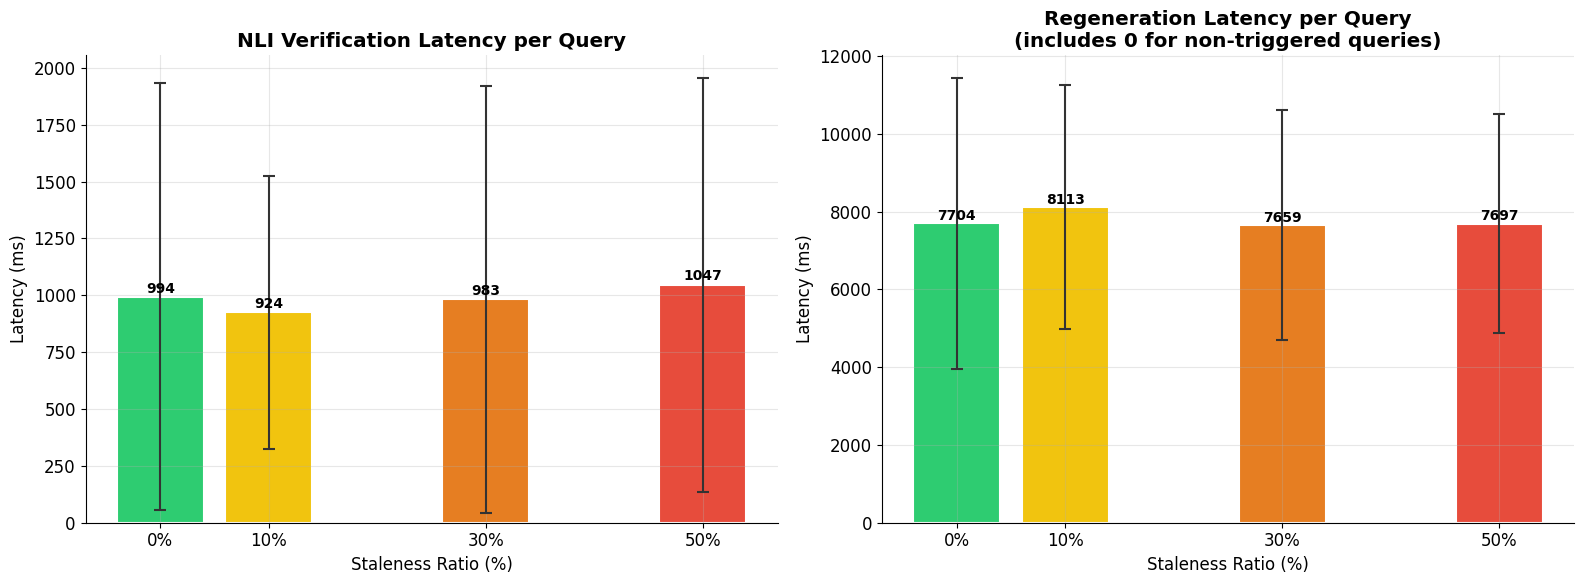

Saved: figures/fig42_verification_latency.png


In [14]:
# ── Fig 42: Verification & Regen latency ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = [COLORS[c] for c in CONDITIONS]

# NLI verification latency
ax = axes[0]
vals = [data['overall'][c]['verification_latency_ms_mean'] for c in CONDITIONS]
stds = [data['overall'][c]['verification_latency_ms_std'] for c in CONDITIONS]
bars = ax.bar(STALENESS_PCTS, vals, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.errorbar(STALENESS_PCTS, vals, yerr=stds, fmt='none', color='#333', capsize=4, capthick=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Latency (ms)')
ax.set_title('NLI Verification Latency per Query', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Regen latency (mean, including zeros for non-regen queries)
ax = axes[1]
vals = [data['overall'][c]['regen_latency_ms_mean'] for c in CONDITIONS]
stds = [data['overall'][c]['regen_latency_ms_std'] for c in CONDITIONS]
bars = ax.bar(STALENESS_PCTS, vals, width=8, color=colors, edgecolor='white', linewidth=1.5)
ax.errorbar(STALENESS_PCTS, vals, yerr=stds, fmt='none', color='#333', capsize=4, capthick=1.5)
ax.set_xlabel('Staleness Ratio (%)')
ax.set_ylabel('Latency (ms)')
ax.set_title('Regeneration Latency per Query\n(includes 0 for non-triggered queries)', fontweight='bold')
ax.set_xticks(STALENESS_PCTS)
ax.set_xticklabels(['0%', '10%', '30%', '50%'])
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/fig42_verification_latency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fig42_verification_latency.png')

## 9. Summary Statistics

In [15]:
# ── Key findings ──
print('=' * 60)
print('KEY FINDINGS — VERIFICATION STAGE')
print('=' * 60)

print(f'\n1. ENTAILMENT FAILURE RATE')
for cond in CONDITIONS:
    d = data['overall'][cond]
    print(f'   {CONDITION_LABELS[cond]:>12}: {d["entailment_failure_mean"]:.4f} '
          f'({int(d["entailment_failure_sum"])}/{d["n"]} queries failed)')

print(f'\n2. REGENERATION TRIGGER RATE')
for cond in CONDITIONS:
    d = data['overall'][cond]
    print(f'   {CONDITION_LABELS[cond]:>12}: {d["regeneration_triggered_mean"]:.4f} '
          f'({int(d["regeneration_triggered_sum"])} regenerations)')

print(f'\n3. ENTAILED AFTER REGEN (recovery)')
for cond in CONDITIONS:
    d = data['overall'][cond]
    print(f'   {CONDITION_LABELS[cond]:>12}: {d["entailed_after_regen_mean"]:.4f}')

print(f'\n4. TOTAL COST PER VERIFIED ANSWER')
for cond in CONDITIONS:
    d = data['overall'][cond]
    print(f'   {CONDITION_LABELS[cond]:>12}: ${d["total_cost_usd_mean"]:.6f}/query '
          f'(gen: ${d["generation_cost_usd_mean"]:.6f} + regen: ${d["regen_cost_usd_mean"]:.6f})')

print(f'\n5. TOTAL COST (sum)')
for cond in CONDITIONS:
    d = data['overall'][cond]
    print(f'   {CONDITION_LABELS[cond]:>12}: ${d["total_cost_usd_sum"]:.4f}')

grand_total = sum(data['overall'][c]['total_cost_usd_sum'] for c in CONDITIONS)
print(f'\n   Grand total across all conditions: ${grand_total:.4f}')

# Delta analysis
print(f'\n6. FRESH vs. STALE-50% DELTA')
fresh = data['overall']['fresh']
stale50 = data['overall']['stale_50']
for label, key in [
    ('Entailment failure', 'entailment_failure_mean'),
    ('Regen trigger rate', 'regeneration_triggered_mean'),
    ('Total cost/query', 'total_cost_usd_mean'),
]:
    f_val = fresh[key]
    s_val = stale50[key]
    delta = s_val - f_val
    pct = delta / f_val * 100 if f_val > 0 else float('inf')
    print(f'   {label:<25}: {f_val:.4f} -> {s_val:.4f} ({delta:+.4f}, {pct:+.1f}%)')

KEY FINDINGS — VERIFICATION STAGE

1. ENTAILMENT FAILURE RATE
     Fresh (0%): 0.9377 (271/289 queries failed)
      Stale 10%: 0.9446 (273/289 queries failed)
      Stale 30%: 0.9377 (271/289 queries failed)
      Stale 50%: 0.9585 (277/289 queries failed)

2. REGENERATION TRIGGER RATE
     Fresh (0%): 0.9377 (271 regenerations)
      Stale 10%: 0.9446 (273 regenerations)
      Stale 30%: 0.9377 (271 regenerations)
      Stale 50%: 0.9585 (277 regenerations)

3. ENTAILED AFTER REGEN (recovery)
     Fresh (0%): 0.0934
      Stale 10%: 0.0796
      Stale 30%: 0.1003
      Stale 50%: 0.0588

4. TOTAL COST PER VERIFIED ANSWER
     Fresh (0%): $0.001453/query (gen: $0.000531 + regen: $0.000922)
      Stale 10%: $0.001518/query (gen: $0.000532 + regen: $0.000986)
      Stale 30%: $0.001504/query (gen: $0.000532 + regen: $0.000972)
      Stale 50%: $0.001526/query (gen: $0.000528 + regen: $0.000998)

5. TOTAL COST (sum)
     Fresh (0%): $0.4199
      Stale 10%: $0.4386
      Stale 30%: $0.43

In [16]:
# ── Export summary table ──
summary_df = df_overview[['Staleness %', 'Entailment Failure Rate', 'Regen Trigger Rate',
                           'Entailed After Regen', 'Gen Cost/Query USD',
                           'Regen Cost/Query USD', 'Total Cost/Query USD',
                           'Total Cost USD']].copy()
summary_df.to_csv('../results/verification_summary_table.csv')
print('Exported: results/verification_summary_table.csv')
print()
print(summary_df.to_string(float_format='{:.4f}'.format))

Exported: results/verification_summary_table.csv

            Staleness %  Entailment Failure Rate  Regen Trigger Rate  Entailed After Regen  Gen Cost/Query USD  Regen Cost/Query USD  Total Cost/Query USD  Total Cost USD
Condition                                                                                                                                                                 
Fresh (0%)            0                   0.9377              0.9377                0.0934              0.0005                0.0009                0.0015          0.4199
Stale 10%            10                   0.9446              0.9446                0.0796              0.0005                0.0010                0.0015          0.4386
Stale 30%            30                   0.9377              0.9377                0.1003              0.0005                0.0010                0.0015          0.4348
Stale 50%            50                   0.9585              0.9585                0.0588     

## 10. Findings and Results

Key questions answered:

- **Does staleness increase hallucination?** Compare entailment failure rate across conditions — higher failure = more answers inconsistent with context.
- **Regeneration cost of staleness:** Higher regen trigger rate means more API calls and higher cost per verified answer. This is the hidden tax of stale corpora.
- **Recovery effectiveness:** Does regeneration actually fix hallucinations, or does conflicting context make recovery impossible regardless of retries?
- **Time-sensitive gap:** Do time-sensitive queries show higher hallucination rates under staleness, consistent with the temporal-semantic trap observed in upstream stages?
- **Domain vulnerability:** Which enterprise domains are most prone to hallucination when context is contaminated with stale content?
- **Upstream predictors:** Do context assembly signals (contradiction density, stale token ratio) reliably predict entailment failure at the verification stage?